In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [44]:
with open("../data/raw/train.tsv", "r", encoding="utf-8") as f:
    for i in range(3):
        print(f.readline())


2635.json	false	Says the Annies List political group supports third-trimester abortions on demand.	abortion	dwayne-bohac	State representative	Texas	republican	0	1	0	0	0	a mailer

10540.json	half-true	When did the decline of coal start? It started when natural gas took off that started to begin in (President George W.) Bushs administration.	energy,history,job-accomplishments	scott-surovell	State delegate	Virginia	democrat	0	0	1	1	0	a floor speech.

324.json	mostly-true	Hillary Clinton agrees with John McCain "by voting to give George Bush the benefit of the doubt on Iran."	foreign-policy	barack-obama	President	Illinois	democrat	70	71	160	163	9	Denver



In [45]:
cols = [
    "id",
    "label",
    "statement",
    "subject",
    "speaker",
    "speaker_job",
    "state",
    "party",
    "barely_true_counts",
    "false_counts",
    "half_true_counts",
    "mostly_true_counts",
    "pants_fire_counts",
    "context"
]

In [46]:
train_df = pd.read_csv("../data/raw/train.tsv", sep="\t", header=None, names=cols)
test_df = pd.read_csv("../data/raw/test.tsv", sep="\t", header=None, names=cols)
valid_df = pd.read_csv("../data/raw/valid.tsv", sep="\t", header=None, names=cols)

In [47]:
print(train_df.shape)
train_df.head()

(10240, 14)


,id,label,statement,subject,speaker,speaker_job,state,party,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_fire_counts,context
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN


In [48]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10240 entries, 0 to 10239
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  10240 non-null  object 
 1   label               10240 non-null  object 
 2   statement           10240 non-null  object 
 3   subject             10238 non-null  object 
 4   speaker             10238 non-null  object 
 5   speaker_job         7342 non-null   object 
 6   state               8030 non-null   object 
 7   party               10238 non-null  object 
 8   barely_true_counts  10238 non-null  float64
 9   false_counts        10238 non-null  float64
 10  half_true_counts    10238 non-null  float64
 11  mostly_true_counts  10238 non-null  float64
 12  pants_fire_counts   10238 non-null  float64
 13  context             10138 non-null  object 
dtypes: float64(5), object(9)
memory usage: 1.1+ MB


In [49]:
train_df.isnull().sum()

id                       0
label                    0
statement                0
subject                  2
speaker                  2
speaker_job           2898
state                 2210
party                    2
barely_true_counts       2
false_counts             2
half_true_counts         2
mostly_true_counts       2
pants_fire_counts        2
context                102
dtype: int64

In [50]:
train_df["label"].value_counts()

label
half-true      2114
false          1995
mostly-true    1962
true           1676
barely-true    1654
pants-fire      839
Name: count, dtype: int64

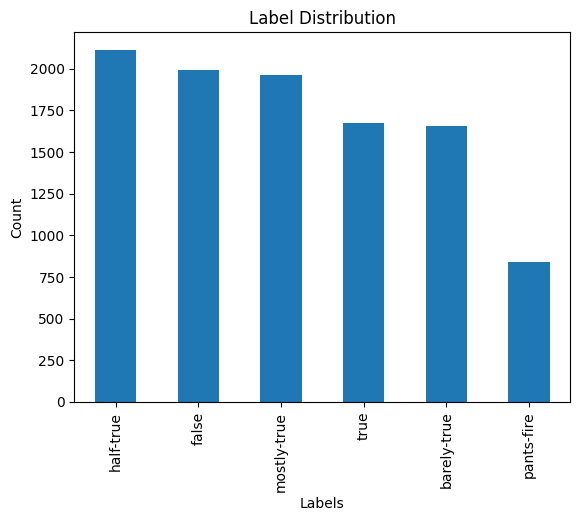

In [51]:
train_df["label"].value_counts().plot(kind="bar")

plt.title("Label Distribution")
plt.xlabel("Labels")
plt.ylabel("Count")

plt.show()

In [52]:
train_df["text_length"] = train_df["statement"].apply(len)

In [53]:
train_df["text_length"].describe()

count    10240.000000
mean       106.918750
std         59.917722
min         11.000000
25%         73.000000
50%         99.000000
75%        132.250000
max       3192.000000
Name: text_length, dtype: float64

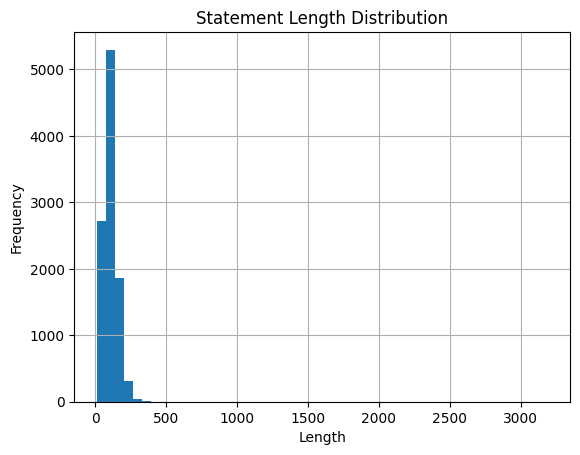

In [54]:
train_df["text_length"].hist(bins=50)

plt.title("Statement Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")

plt.show()

## Preprocessing

In [55]:
train_df[["statement", "label"]].sample(10)

,statement,label
8163,As we watch the news from Colorado with horror...,half-true
2952,On the Keystone XL pipeline,true
5612,John McCain voted against establishing a natio...,true
7028,California has more kids in poverty ... than v...,mostly-true
5233,Tuition-free public universities and colleges ...,barely-true
6709,The American people dont want us to raise taxes.,barely-true
9514,"Thurbert Baker kept a teen in jail ""who didn't...",false
6390,"Says that except for Donald Trump, every other...",mostly-true
5827,"Rubio's ""got more experience than Obama had.""",barely-true
3607,The Declaration of Independence was written on...,false


In [56]:
train_data = train_df[["statement", "label"]].copy()
valid_data = valid_df[["statement", "label"]].copy()
test_data = test_df[["statement", "label"]].copy()

In [57]:
def convert_label(label):
    if label in ["true", "mostly-true"]:
        return "REAL"
    else:
        return "FAKE"

In [58]:
for data in [train_data, valid_data, test_data]:
    
    data["target"] = data["label"].apply(convert_label)

    data["target_encoded"] = data["target"].map({"FAKE": 0, "REAL": 1})

In [59]:
print(train_data["target"].value_counts())
print(test_data["target"].value_counts())
print(valid_data["target"].value_counts())

target
FAKE    6602
REAL    3638
Name: count, dtype: int64
target
FAKE    818
REAL    449
Name: count, dtype: int64
target
FAKE    864
REAL    420
Name: count, dtype: int64


In [60]:
train_data.head()

,statement,label,target,target_encoded
0,Says the Annies List political group supports ...,false,FAKE,0
1,When did the decline of coal start? It started...,half-true,FAKE,0
2,"Hillary Clinton agrees with John McCain ""by vo...",mostly-true,REAL,1
3,Health care reform legislation is likely to ma...,false,FAKE,0
4,The economic turnaround started at the end of ...,half-true,FAKE,0


In [61]:
train_data["target_encoded"].value_counts()

target_encoded
0    6602
1    3638
Name: count, dtype: int64

In [62]:
X_train = train_data["statement"]
y_train = train_data["target_encoded"]

X_valid = valid_data["statement"]
y_valid = valid_data["target_encoded"]

X_test = test_data["statement"]
y_test = test_data["target_encoded"]

In [63]:
print(X_train.shape, y_train.shape)
print(X_valid.shape, y_valid.shape)
print(X_test.shape, y_test.shape)

(10240,) (10240,)
(1284,) (1284,)
(1267,) (1267,)


## Model building

In [64]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report


In [65]:
baseline_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000)),
    ("model", LogisticRegression(max_iter=1000))
])

In [66]:
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_valid)

y_proba = baseline_model.predict_proba(X_valid)[:, 1]

In [67]:
print("Accuracy:", accuracy_score(y_valid, y_pred))
print("Precision:", precision_score(y_valid, y_pred))
print("Recall:", recall_score(y_valid, y_pred))
print("F1:", f1_score(y_valid, y_pred))
print("ROC-AUC:", roc_auc_score(y_valid, y_proba))

print(classification_report(y_valid, y_pred))

Accuracy: 0.676791277258567
Precision: 0.5118483412322274
Recall: 0.2571428571428571
F1: 0.34231378763866877
ROC-AUC: 0.6701967592592593
              precision    recall  f1-score   support

           0       0.71      0.88      0.79       864
           1       0.51      0.26      0.34       420

    accuracy                           0.68      1284
   macro avg       0.61      0.57      0.56      1284
weighted avg       0.64      0.68      0.64      1284



In [68]:
from sklearn.naive_bayes import MultinomialNB

nb_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000)),
    ("model", MultinomialNB())
])

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_valid)
y_proba_nb = nb_model.predict_proba(X_valid)[:, 1]

print("Accuracy:", accuracy_score(y_valid, y_pred_nb))
print("Precision:", precision_score(y_valid, y_pred_nb))
print("Recall:", recall_score(y_valid, y_pred_nb))
print("F1:", f1_score(y_valid, y_pred_nb))
print("ROC-AUC:", roc_auc_score(y_valid, y_proba_nb))

print(classification_report(y_valid, y_pred_nb))

Accuracy: 0.6651090342679128
Precision: 0.4489795918367347
Recall: 0.10476190476190476
F1: 0.16988416988416988
ROC-AUC: 0.6564869929453262
              precision    recall  f1-score   support

           0       0.68      0.94      0.79       864
           1       0.45      0.10      0.17       420

    accuracy                           0.67      1284
   macro avg       0.57      0.52      0.48      1284
weighted avg       0.61      0.67      0.59      1284

